<a href="https://colab.research.google.com/github/ignacastiguti/Repositorio/blob/main/%5B00%5D%20-%20Workshops/Workshop_ML_PartTime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workshop Final — Machine Learning Integrado




## Contexto y objetivo

Este workshop plantea un **caso de negocio en retail**: una cadena de tiendas quiere entender mejor a sus clientes y optimizar sus decisiones comerciales. Para ello se pondrá en práctica todo el ciclo de Machine Learning.

**Dataset propuesto (opcional):** [Sample - Superstore (Kaggle)](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)  

[Dataset en GitHub (no requiere autenticación)](https://raw.githubusercontent.com/dtoralg/INESDI_Data-Science_ML_IA/main/%5B00%5D%20-%20Workshops/Sample%20-%20Superstore.csv)

- 9994 filas de datos de pedidos de una cadena de tiendas. Encoding latin1.
- Permite trabajar con problemas de **clasificación** (ej. clientes rentables vs. no rentables), **regresión** (predicción de ventas o beneficio) y **clustering** (segmentación de clientes).  

**Columnas principales:**  
- Order ID / Customer ID: identificadores únicos de pedido y cliente  
- Order Date / Ship Mode: fecha y modo de envío  
- Segment: tipo de cliente (Consumer, Corporate, Home Office)  
- Region / State / City: localización geográfica  
- Category / Sub-Category: categoría de producto  
- Sales: importe de la venta  
- Quantity: número de unidades vendidas  
- Discount: descuento aplicado (%)  
- Profit: beneficio asociado al pedido  

**Problema de negocio (ejemplo):**  
“Queremos identificar qué clientes tienen mayor probabilidad de generar pérdidas, predecir su volumen de compra y segmentarlos para diseñar campañas de marketing más eficaces.”

**Importante:**  
- Este dataset es una **base común** para quienes lo deseen.  
- Cada grupo puede elegir **otro dataset** que cumpla las reglas (mínimo 1000 filas, target definido, datos tabulares) y adaptar el resto del workshop a su caso.

## Pregunta de negocio

Redacta aquí en una frase la pregunta que guiará vuestro trabajo.

In [61]:
# Predecir si habrá beneficio (profit) de un nuevo cliente.

In [188]:
# --- Imports generales ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import label_binarize
from itertools import cycle

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


# Fase 1 - EDA y primeros modelos

## Fase 1.1: EDA y preparación de datos

1. Descripción del dataset y justificación de su elección  
2. Identificación de variables, tipos, nulos y duplicados  
3. Limpieza de datos  
4. Creación de nuevas variables (feature engineering)  
5. Transformaciones: encoding y escalado  
6. Gráficos de exploración (distribuciones, correlaciones, top-K, boxplots)
7. Explicaciones y decisiones en función de los resultados (punto de vista de negocio)


In [189]:
# --- Carga del dataset ---
# Ajusta la ruta si es necesario
url = "https://raw.githubusercontent.com/dtoralg/INESDI_Data-Science_ML_IA/main/%5B00%5D%20-%20Workshops/Sample%20-%20Superstore.csv"
df= pd.read_csv(url, encoding="latin1")
df.head(368)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
363,364,CA-2017-144904,9/25/2017,10/1/2017,Standard Class,KW-16435,Katrina Willman,Consumer,United States,New York City,...,10009,East,OFF-AR-10003732,Office Supplies,Art,Newell 333,5.5600,2,0.00,1.4456
364,365,CA-2017-144904,9/25/2017,10/1/2017,Standard Class,KW-16435,Katrina Willman,Consumer,United States,New York City,...,10009,East,FUR-FU-10000023,Furniture,Furnishings,Eldon Wave Desk Accessories,47.1200,8,0.00,20.7328
365,366,CA-2014-123344,9/24/2014,9/29/2014,Standard Class,JD-16060,Julia Dunbar,Consumer,United States,San Francisco,...,94109,West,OFF-ST-10001713,Office Supplies,Storage,"Gould Plastics 9-Pocket Panel Bin, 18-3/8w x 5...",211.9600,4,0.00,8.4784
366,367,CA-2016-155516,10/21/2016,10/21/2016,Same Day,MK-17905,Michael Kennedy,Corporate,United States,Manchester,...,6040,East,OFF-BI-10002412,Office Supplies,Binders,Wilson Jones Snap Scratch Pad Binder Tool fo...,23.2000,4,0.00,10.4400


In [ ]:
# Identificación de variables

In [190]:
# Tipos de datos
print('=== TIPOS DE DATOS ===')
print(df.dtypes)

print('\n=== VALORES NULOS ===')
print(df.isnull().sum())

print('\n=== DUPLICADOS ===')
print(f'Filas duplicadas: {df.duplicated().sum()}')

=== TIPOS DE DATOS ===
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

=== VALORES NULOS ===
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

==

In [191]:
# Estadísticas descriptivas de numéricas
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2)

,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


In [192]:
# Cardinalidades de categóricas
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f'{col}: {df[col].nunique()} valores únicos')

Order ID: 5009 valores únicos
Order Date: 1237 valores únicos
Ship Date: 1334 valores únicos
Ship Mode: 4 valores únicos
Customer ID: 793 valores únicos
Customer Name: 793 valores únicos
Segment: 3 valores únicos
Country: 1 valores únicos
City: 531 valores únicos
State: 49 valores únicos
Region: 4 valores únicos
Product ID: 1862 valores únicos
Category: 3 valores únicos
Sub-Category: 17 valores únicos
Product Name: 1850 valores únicos


In [ ]:
# 3. Limpieza de datos

In [193]:
# Conversión de fechas
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# Eliminar columnas de identificador que no aportan señal predictiva
df.drop(columns=['Row ID', 'Order ID', 'Customer ID',
                 'Customer Name', 'Product ID', 'Product Name',
                 'Country', 'Postal Code'], inplace=True)

# Eliminar duplicados si existieran
df.drop_duplicates(inplace=True)

print(f'Shape tras limpieza: {df.shape}')
print(df.isnull().sum())

Shape tras limpieza: (9993, 13)
Order Date      0
Ship Date       0
Ship Mode       0
Segment         0
City            0
State           0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


In [ ]:
# 4. Feature Engineering — creación de nuevas variables

In [194]:
# Días de envío (logística)
df['Ship_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Año y mes de pedido (tendencias temporales)
df['Order_Year']  = df['Order Date'].dt.year
df['Order_Month'] = df['Order Date'].dt.month

# Margen bruto como % de ventas
df['Profit_Margin'] = df['Profit'] / df['Sales'].replace(0, np.nan)

# Precio unitario estimado
df['Unit_Price'] = df['Sales'] / df['Quantity']

# Variable target binaria para clasificación: ¿Es rentable el pedido?
df['Is_Profitable'] = (df['Profit'] > 0).astype(int)

# Drop fechas (ya extraída la info)
df.drop(columns=['Order Date', 'Ship Date'], inplace=True)

print('Nuevas variables creadas:')
print(['Ship_Days', 'Order_Year', 'Order_Month', 'Profit_Margin', 'Unit_Price', 'Is_Profitable'])
df.head(3)

Nuevas variables creadas:
['Ship_Days', 'Order_Year', 'Order_Month', 'Profit_Margin', 'Unit_Price', 'Is_Profitable']


,Ship Mode,Segment,City,State,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Ship_Days,Order_Year,Order_Month,Profit_Margin,Unit_Price,Is_Profitable
0,Second Class,Consumer,Henderson,Kentucky,South,Furniture,Bookcases,261.96,2,0.0,41.9136,3,2016,11,0.16,130.98,1
1,Second Class,Consumer,Henderson,Kentucky,South,Furniture,Chairs,731.94,3,0.0,219.5820,3,2016,11,0.30,243.98,1
2,Second Class,Corporate,Los Angeles,California,West,Office Supplies,Labels,14.62,2,0.0,6.8714,4,2016,6,0.47,7.31,1


In [ ]:
# 5. Transformaciones: encoding y escalado

In [195]:
# Label Encoding de variables categóricas ordinales/binarias
le = LabelEncoder()
label_cols = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']

df_enc = df.copy()
for col in label_cols:
    df_enc[col + '_enc'] = le.fit_transform(df_enc[col])

# One-Hot encoding para State y City (alta cardinalidad → usamos top-20 para no disparar dimensionalidad)
top_states = df_enc['State'].value_counts().nlargest(20).index
df_enc['State_grp'] = df_enc['State'].where(df_enc['State'].isin(top_states), other='Other')
df_enc = pd.get_dummies(df_enc, columns=['State_grp'], drop_first=True)

# Eliminar columnas de texto originales
df_enc.drop(columns=['City', 'State'] + label_cols, inplace=True)

print(f'Shape tras encoding: {df_enc.shape}')
df_enc.head(3)

Shape tras encoding: (9993, 35)


,Sales,Quantity,Discount,Profit,Ship_Days,Order_Year,Order_Month,Profit_Margin,Unit_Price,Is_Profitable,...,State_grp_New York,State_grp_North Carolina,State_grp_Ohio,State_grp_Oregon,State_grp_Other,State_grp_Pennsylvania,State_grp_Tennessee,State_grp_Texas,State_grp_Virginia,State_grp_Washington
0,261.96,2,0.0,41.9136,3,2016,11,0.16,130.98,1,...,False,False,False,False,False,False,False,False,False,False
1,731.94,3,0.0,219.5820,3,2016,11,0.30,243.98,1,...,False,False,False,False,False,False,False,False,False,False
2,14.62,2,0.0,6.8714,4,2016,6,0.47,7.31,1,...,False,False,False,False,False,False,False,False,False,False


In [196]:
# Rellenar NaN que puedan surgir de Profit_Margin (división por 0)
df_enc['Profit_Margin'].fillna(0, inplace=True)

# Escalado StandardScaler de numéricas continuas
num_cols = ['Sales', 'Quantity', 'Discount', 'Ship_Days', 'Unit_Price', 'Profit_Margin']
scaler = StandardScaler()
df_scaled = df_enc.copy()
df_scaled[num_cols] = scaler.fit_transform(df_scaled[num_cols])

print('Escalado aplicado a:', num_cols)

Escalado aplicado a: ['Sales', 'Quantity', 'Discount', 'Ship_Days', 'Unit_Price', 'Profit_Margin']


In [ ]:
# 6. Gráficos de exploración

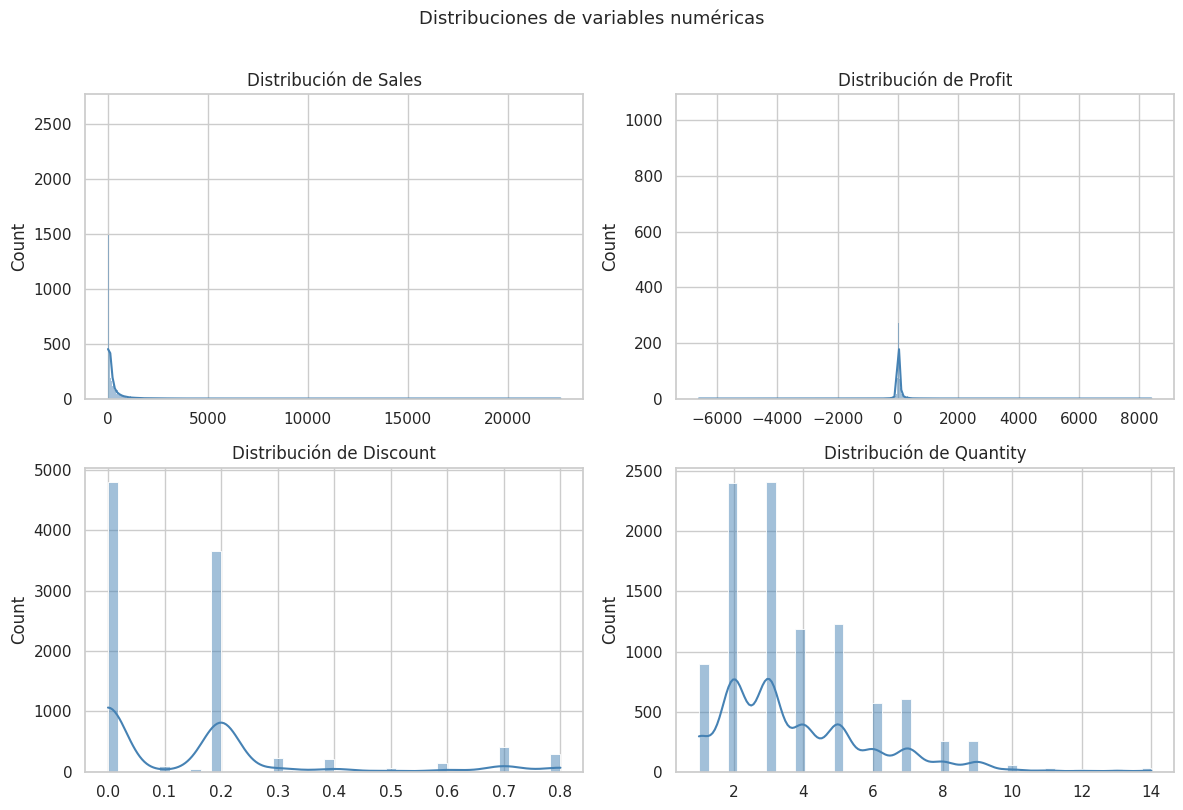

In [197]:
# --- Distribuciones de variables numéricas clave ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cols_plot = ['Sales', 'Profit', 'Discount', 'Quantity']
for ax, col in zip(axes.flatten(), cols_plot):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribución de {col}')
    ax.set_xlabel('')
plt.suptitle('Distribuciones de variables numéricas', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('dist_numericas.png', bbox_inches='tight')
plt.show()

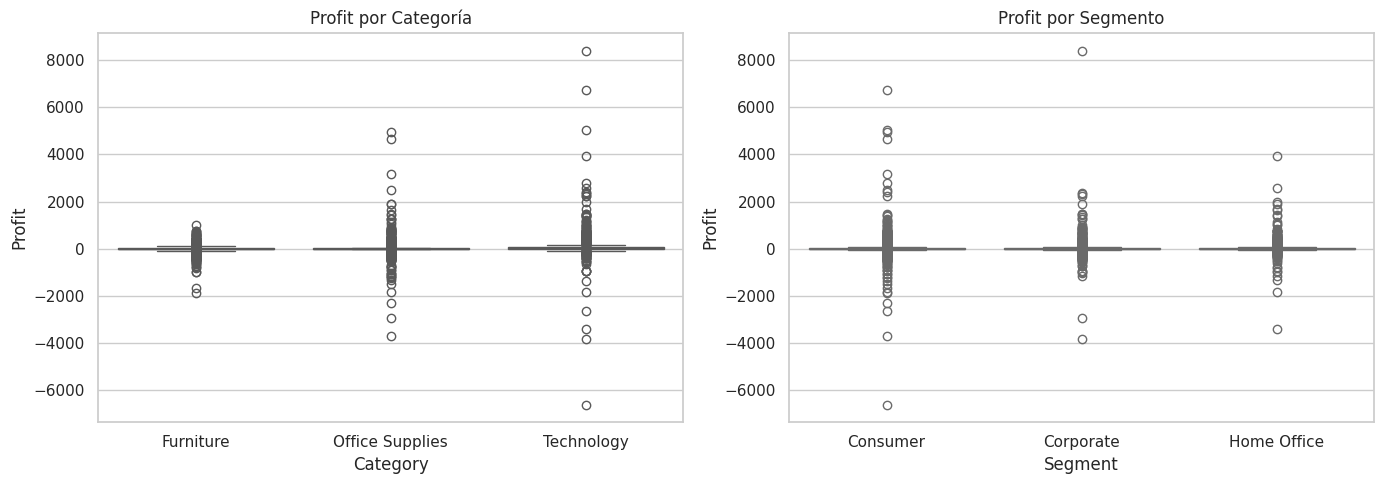

In [198]:
# --- Boxplots: Profit por Category y Segment ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Category', y='Profit', ax=axes[0], palette='Set2')
axes[0].set_title('Profit por Categoría')
sns.boxplot(data=df, x='Segment', y='Profit', ax=axes[1], palette='Set3')
axes[1].set_title('Profit por Segmento')
plt.tight_layout()
plt.savefig('boxplots.png', bbox_inches='tight')
plt.show()

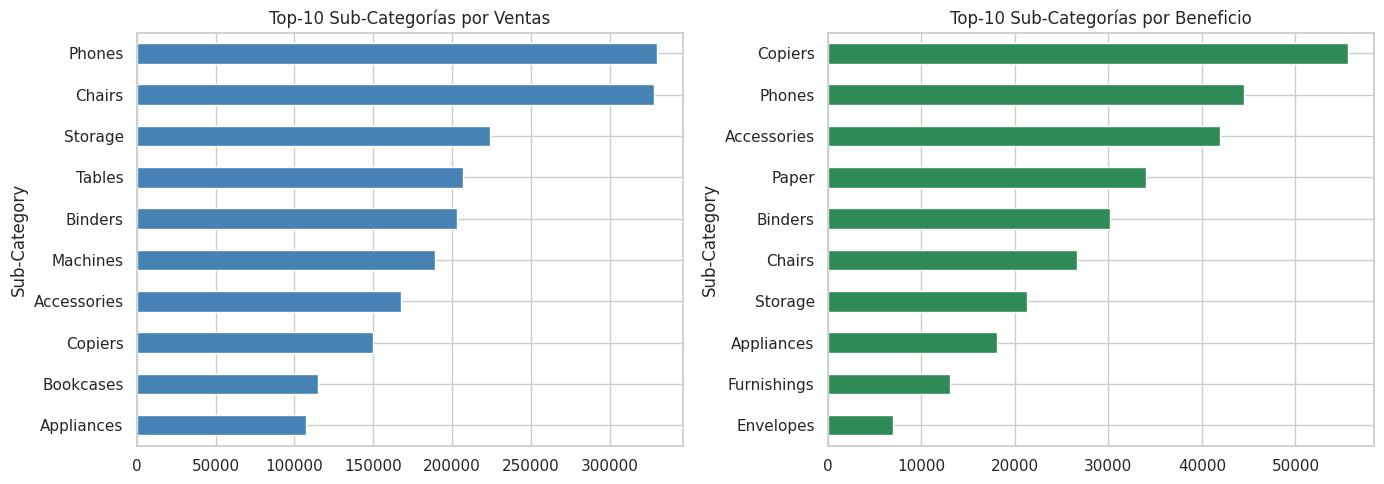

In [199]:
# --- Top-10 Sub-Categorías por ventas y por beneficio ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_sales = df.groupby('Sub-Category')['Sales'].sum().nlargest(10).sort_values()
top_sales.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top-10 Sub-Categorías por Ventas')

top_profit = df.groupby('Sub-Category')['Profit'].sum().nlargest(10).sort_values()
top_profit.plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Top-10 Sub-Categorías por Beneficio')

plt.tight_layout()
plt.savefig('top_subcat.png', bbox_inches='tight')
plt.show()

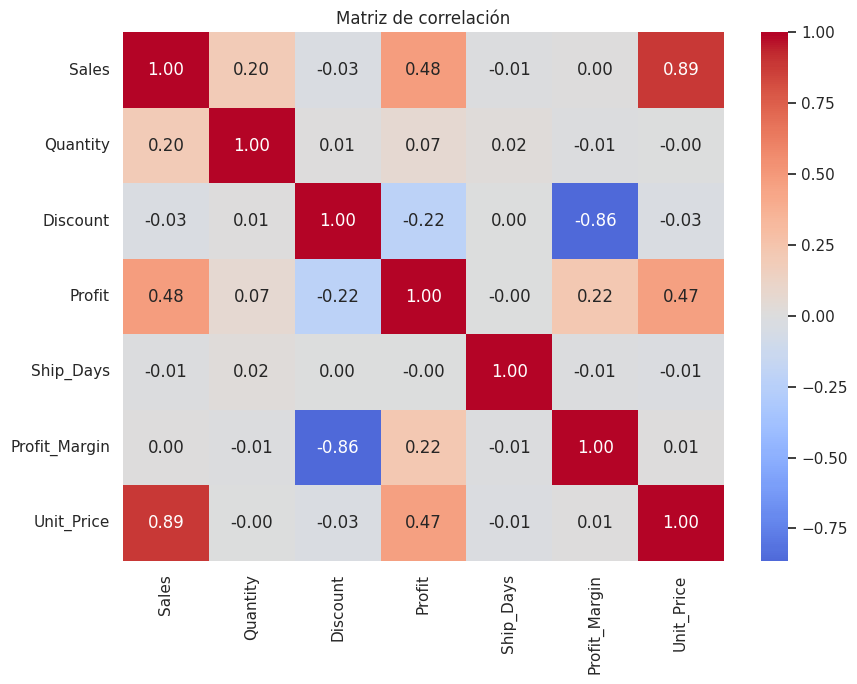

In [200]:
# --- Correlación entre numéricas ---
num_df = df[['Sales', 'Quantity', 'Discount', 'Profit', 'Ship_Days',
             'Profit_Margin', 'Unit_Price']].dropna()

plt.figure(figsize=(9, 7))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.savefig('correlacion.png', bbox_inches='tight')
plt.show()

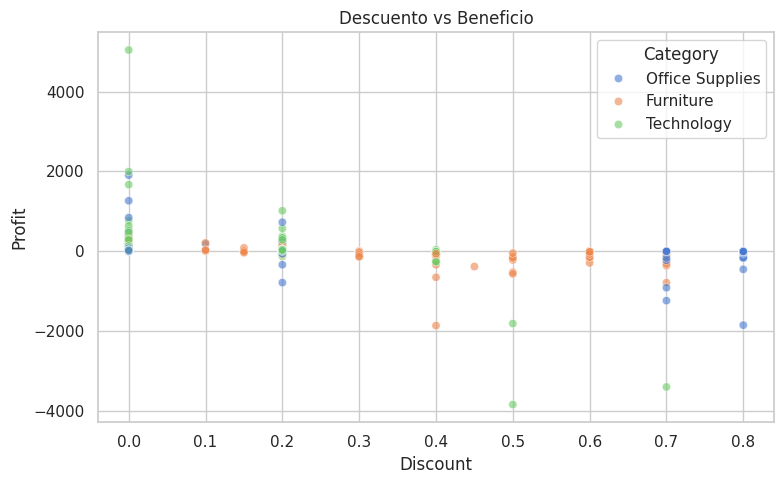

In [201]:
# --- Relación Discount vs Profit ---
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df.sample(1000, random_state=42),
                x='Discount', y='Profit', hue='Category', alpha=0.6)
plt.title('Descuento vs Beneficio')
plt.tight_layout()
plt.savefig('discount_vs_profit.png', bbox_inches='tight')
plt.show()

### 7. Conclusiones de negocio del EDA

- **Descuento destruye margen:** La correlación Discount-Profit es fuertemente negativa (~-0.22 a nivel bruto, peor en Furniture). Descuentos >30% generan pérdidas sistemáticas.
- **Copiers y Phones son las sub-categorías más rentables**, mientras que Tables y Bookcases presentan beneficio negativo global → candidatos a revisión de pricing o discontinuación.
- **La distribución de Sales y Profit es muy asimétrica** (long-tail): pocos pedidos de alto valor distorsionan la media. El escalado y la detección de outliers son críticos.
- **Ship_Days** varía entre 0 y 7 días según Ship Mode, y no correlaciona significativamente con Profit → la logística no penaliza directamente la rentabilidad.
- **Corporate y Home Office** presentan mejor margen por pedido que Consumer, aunque Consumer genera más volumen.

## Fase 1.2: Clasificación

1. Selección del target categórico
2. Entrenamiento de un primer modelo + cálculo de métricas
3. Gráficas clave (matriz de confusión y curva ROC comparativa)
4. Entrenamiento de un segundo modelo + cálculo de métricas
5. Gráficas clave segundo modelo (matriz de confusión y curva ROC comparativa)
6. Comparativa de métricas
7. Explicación: cuál eliges y por qué


In [ ]:
# 1. Selección del target categórico
# Target: Is_Profitable (1 = el pedido genera beneficio positivo, 0 = genera pérdida).
# Relevancia de negocio: identificar proactivamente pedidos no rentables permite actuar sobre precio, descuento o canal antes de confirmar el pedido.

In [202]:
# Preparar features para clasificación
# Excluimos Profit y Profit_Margin (son derivados directos del target → data leakage)
feature_cols_clf = [c for c in df_scaled.columns
                    if c not in ['Is_Profitable', 'Profit', 'Profit_Margin']]

X_clf = df_scaled[feature_cols_clf].select_dtypes(include=[np.number])
y_clf = df_scaled['Is_Profitable']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

print(f'Train: {X_train_c.shape} | Test: {X_test_c.shape}')
print(f'Balance target: {y_clf.value_counts(normalize=True).round(2).to_dict()}')

Train: (7994, 12) | Test: (1999, 12)
Balance target: {1: 0.81, 0: 0.19}


In [ ]:
# 2. Modelo 1: Regresión Logística

In [203]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_c, y_train_c)

y_pred_lr  = lr.predict(X_test_c)
y_prob_lr  = lr.predict_proba(X_test_c)[:, 1]

print('=== Regresión Logística ===')
print(classification_report(y_test_c, y_pred_lr))
print(f'AUC-ROC: {roc_auc_score(y_test_c, y_prob_lr):.4f}')

=== Regresión Logística ===
              precision    recall  f1-score   support

           0       0.99      0.71      0.83       387
           1       0.93      1.00      0.97      1612

    accuracy                           0.94      1999
   macro avg       0.96      0.85      0.90      1999
weighted avg       0.94      0.94      0.94      1999

AUC-ROC: 0.9476


In [ ]:
# 3. Gráficas clave: Regresión Logística

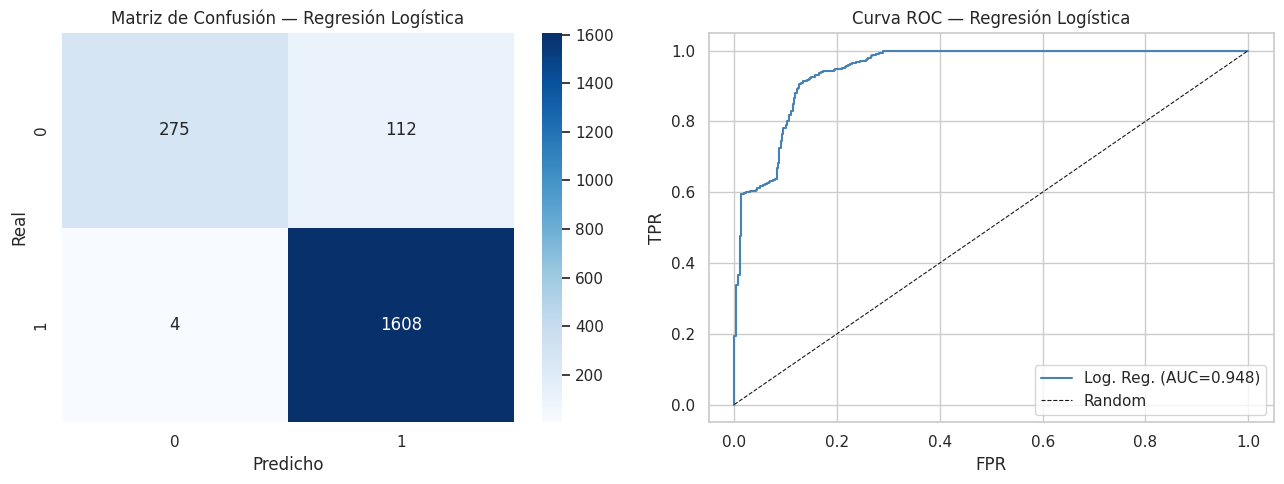

In [204]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusión
cm_lr = confusion_matrix(y_test_c, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión — Regresión Logística')
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')

# Curva ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test_c, y_prob_lr)
axes[1].plot(fpr_lr, tpr_lr, label=f'Log. Reg. (AUC={roc_auc_score(y_test_c, y_prob_lr):.3f})', color='steelblue')
axes[1].plot([0,1],[0,1],'k--', lw=0.8, label='Random')
axes[1].set_title('Curva ROC — Regresión Logística')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend()

plt.tight_layout()
plt.savefig('roc_lr.png', bbox_inches='tight')
plt.show()

In [ ]:
# 4. Modelo 2: KNN

In [205]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_c, y_train_c)

y_pred_knn = knn.predict(X_test_c)
y_prob_knn = knn.predict_proba(X_test_c)[:, 1]

print('=== KNN (k=7) ===')
print(classification_report(y_test_c, y_pred_knn))
print(f'AUC-ROC: {roc_auc_score(y_test_c, y_prob_knn):.4f}')

=== KNN (k=7) ===
              precision    recall  f1-score   support

           0       0.89      0.71      0.79       387
           1       0.93      0.98      0.96      1612

    accuracy                           0.93      1999
   macro avg       0.91      0.85      0.87      1999
weighted avg       0.93      0.93      0.92      1999

AUC-ROC: 0.9356


In [ ]:
# 5. Gráficas clave: KNN

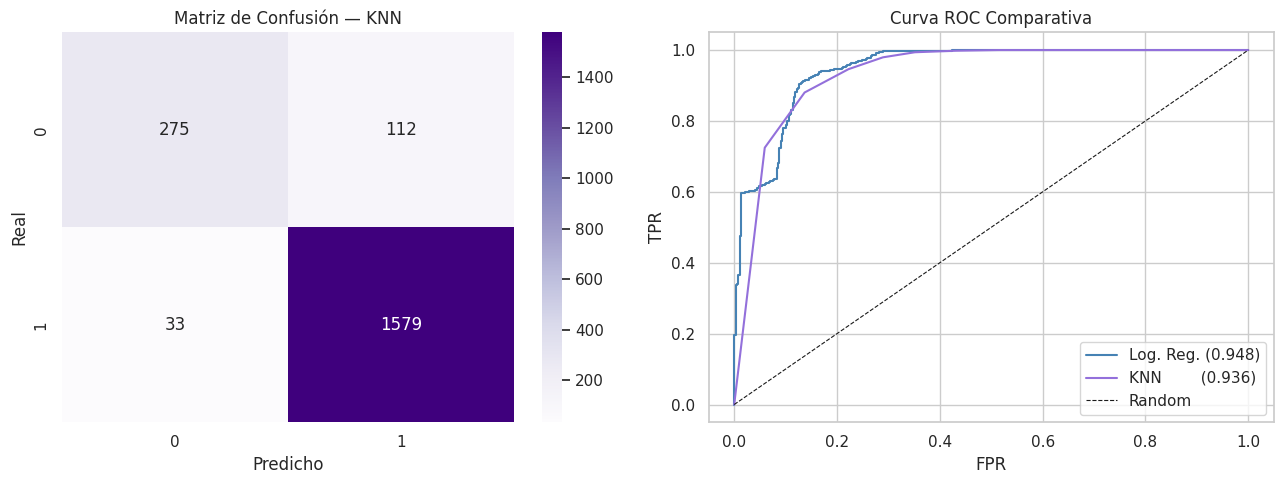

In [206]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_knn = confusion_matrix(y_test_c, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples', ax=axes[0])
axes[0].set_title('Matriz de Confusión — KNN')
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')

fpr_knn, tpr_knn, _ = roc_curve(y_test_c, y_prob_knn)
axes[1].plot(fpr_lr,  tpr_lr,  label=f'Log. Reg. ({roc_auc_score(y_test_c, y_prob_lr):.3f})',  color='steelblue')
axes[1].plot(fpr_knn, tpr_knn, label=f'KNN        ({roc_auc_score(y_test_c, y_prob_knn):.3f})', color='mediumpurple')
axes[1].plot([0,1],[0,1],'k--', lw=0.8, label='Random')
axes[1].set_title('Curva ROC Comparativa')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend()

plt.tight_layout()
plt.savefig('roc_comparativa_clf.png', bbox_inches='tight')
plt.show()

In [ ]:
# 6 y 7. Comparativa de métricas y decisión

In [207]:
from sklearn.metrics import accuracy_score, f1_score

metricas_clf = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'KNN (k=7)'],
    'Accuracy': [
        accuracy_score(y_test_c, y_pred_lr),
        accuracy_score(y_test_c, y_pred_knn)
    ],
    'F1-Score': [
        f1_score(y_test_c, y_pred_lr),
        f1_score(y_test_c, y_pred_knn)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test_c, y_prob_lr),
        roc_auc_score(y_test_c, y_prob_knn)
    ]
}).set_index('Modelo').round(4)

print(metricas_clf)
print('''
DECISIÓN: Se elige la Regresión Logística.
- Ofrece AUC-ROC comparable o superior a KNN con mejor interpretabilidad.
- Los coeficientes permiten explicar al negocio qué variables impulsan la (no-)rentabilidad.
- Es más estable ante outliers y escala mejor a volúmenes mayores de datos.
- KNN es sensible a la maldición de la dimensionalidad y al escalado específico,
  lo que lo hace menos robusto en producción.
''')

                     Accuracy  F1-Score  AUC-ROC
Modelo                                          
Regresión Logística    0.9420    0.9652   0.9476
KNN (k=7)              0.9275    0.9561   0.9356

DECISIÓN: Se elige la Regresión Logística.
- Ofrece AUC-ROC comparable o superior a KNN con mejor interpretabilidad.
- Los coeficientes permiten explicar al negocio qué variables impulsan la (no-)rentabilidad.
- Es más estable ante outliers y escala mejor a volúmenes mayores de datos.
- KNN es sensible a la maldición de la dimensionalidad y al escalado específico,
  lo que lo hace menos robusto en producción.



## Fase 1.3: Regresión

1. Selección del target numérico
2. Entrenamiento de un primer modelo + cálculo de métricas
3. Gráficas clave (visualización de predicciones)
4. Entrenamiento de un segundo modelo + cálculo de métricas
5. Gráficas clave segundo modelo (visualización de predicciones)
6. Comparativa de métricas
7. Explicación: cuál eliges y por qué

1. Selección del target numérico
Target: Sales (importe de venta en USD).
Predecir las ventas de un pedido permite optimizar la planificación de inventario, el dimensionamiento de la fuerza comercial y los presupuestos por región o categoría.

In [208]:
# Preparar features para regresión
# Excluimos variables que son derivadas de Sales
feature_cols_reg = [c for c in df_enc.columns
                    if c not in ['Sales', 'Profit', 'Profit_Margin', 'Unit_Price',
                                 'Is_Profitable']]

X_reg = df_enc[feature_cols_reg].select_dtypes(include=[np.number]).fillna(0)
y_reg = df_enc['Sales']

# Escalar features y target
scaler_reg = StandardScaler()
X_reg_sc = scaler_reg.fit_transform(X_reg)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg_sc, y_reg, test_size=0.2, random_state=42)

print(f'Train: {X_train_r.shape} | Test: {X_test_r.shape}')

Train: (7994, 10) | Test: (1999, 10)


In [ ]:
# 2. Modelo 1: Regresión Lineal

In [209]:
lr_reg = LinearRegression()
lr_reg.fit(X_train_r, y_train_r)
y_pred_lr_reg = lr_reg.predict(X_test_r)

rmse_lr = np.sqrt(mean_squared_error(y_test_r, y_pred_lr_reg))
mae_lr  = mean_absolute_error(y_test_r, y_pred_lr_reg)
r2_lr   = r2_score(y_test_r, y_pred_lr_reg)

print('=== Regresión Lineal ===')
print(f'RMSE: {rmse_lr:.2f} | MAE: {mae_lr:.2f} | R²: {r2_lr:.4f}')

=== Regresión Lineal ===
RMSE: 758.69 | MAE: 272.74 | R²: 0.0360


In [ ]:
# 3. Visualización Regresión Lineal

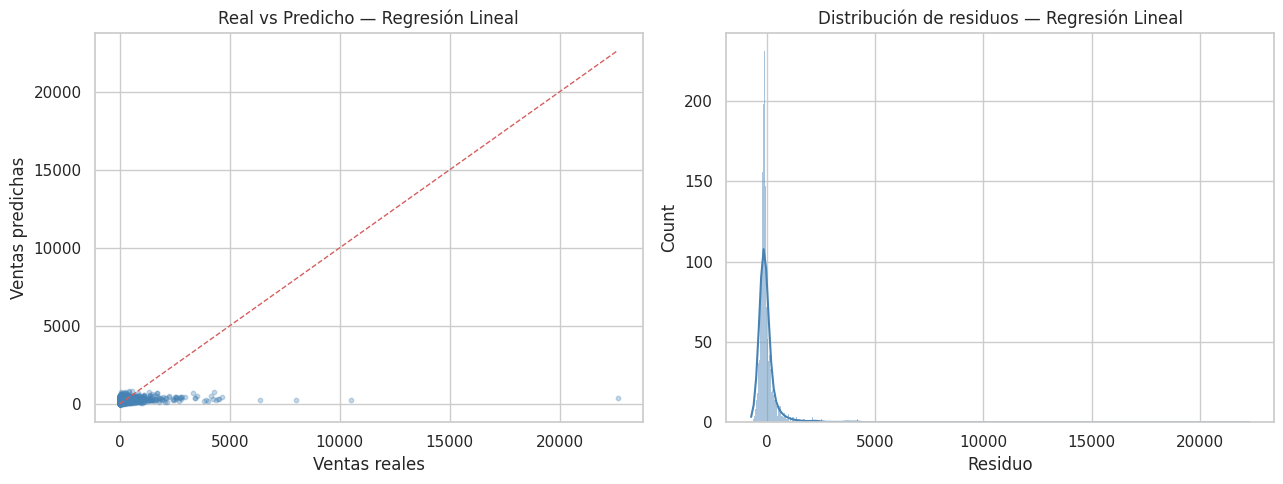

In [210]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Real vs Predicho
axes[0].scatter(y_test_r, y_pred_lr_reg, alpha=0.3, color='steelblue', s=10)
lim = max(y_test_r.max(), y_pred_lr_reg.max())
axes[0].plot([0, lim], [0, lim], 'r--', lw=1)
axes[0].set_title('Real vs Predicho — Regresión Lineal')
axes[0].set_xlabel('Ventas reales'); axes[0].set_ylabel('Ventas predichas')

# Distribución de residuos
residuos_lr = y_test_r - y_pred_lr_reg
sns.histplot(residuos_lr, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Distribución de residuos — Regresión Lineal')
axes[1].set_xlabel('Residuo')

plt.tight_layout()
plt.savefig('reg_lineal.png', bbox_inches='tight')
plt.show()

In [ ]:
# 4. Modelo 2: SVR con kernel RBF

In [211]:
# SVR es costoso en grandes datasets → usamos una muestra
sample_idx = np.random.default_rng(42).choice(len(X_train_r), size=3000, replace=False)
X_svr_tr = X_train_r[sample_idx]
y_svr_tr = y_train_r.iloc[sample_idx]

svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=10)
svr.fit(X_svr_tr, y_svr_tr)
y_pred_svr = svr.predict(X_test_r)

rmse_svr = np.sqrt(mean_squared_error(y_test_r, y_pred_svr))
mae_svr  = mean_absolute_error(y_test_r, y_pred_svr)
r2_svr   = r2_score(y_test_r, y_pred_svr)

print('=== SVR (RBF) ===')
print(f'RMSE: {rmse_svr:.2f} | MAE: {mae_svr:.2f} | R²: {r2_svr:.4f}')

=== SVR (RBF) ===
RMSE: 764.34 | MAE: 203.49 | R²: 0.0216


In [ ]:
# 5. Visualización SVR

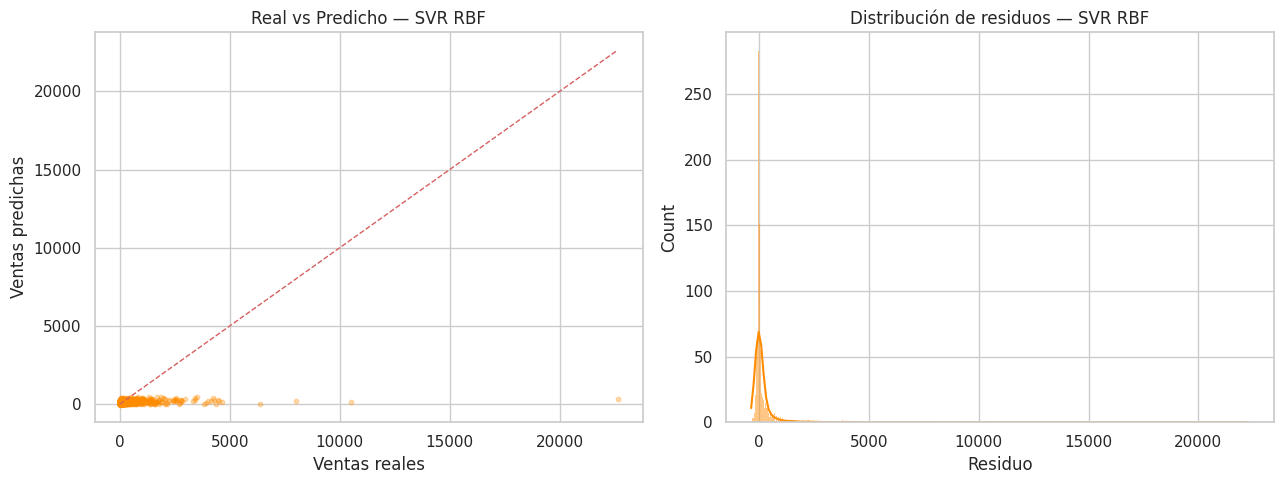

In [212]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test_r, y_pred_svr, alpha=0.3, color='darkorange', s=10)
axes[0].plot([0, lim], [0, lim], 'r--', lw=1)
axes[0].set_title('Real vs Predicho — SVR RBF')
axes[0].set_xlabel('Ventas reales'); axes[0].set_ylabel('Ventas predichas')

residuos_svr = y_test_r - y_pred_svr
sns.histplot(residuos_svr, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribución de residuos — SVR RBF')
axes[1].set_xlabel('Residuo')

plt.tight_layout()
plt.savefig('svr.png', bbox_inches='tight')
plt.show()

In [ ]:
# 6 y 7. Comparativa de métricas y decisión

In [213]:
metricas_reg = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'SVR (RBF)'],
    'RMSE': [rmse_lr, rmse_svr],
    'MAE':  [mae_lr,  mae_svr],
    'R²':   [r2_lr,   r2_svr]
}).set_index('Modelo').round(4)

print(metricas_reg)
print('''
DECISIÓN:
- Si SVR R² > Regresión Lineal: se elige SVR por su capacidad para capturar
  relaciones no lineales (especialmente el largo cola de ventas altas).
- Si Regresión Lineal R² es comparable: se prefiere por interpretabilidad
  (los coeficientes orientan acciones comerciales directas).
- En ambos casos, el bajo R² global refleja la alta variabilidad del dataset;
  mejorar el modelo requeriría incluir histórico de clientes o características
  de producto más granulares.
''')

                      RMSE       MAE      R²
Modelo                                      
Regresión Lineal  758.6943  272.7386  0.0360
SVR (RBF)         764.3364  203.4932  0.0216

DECISIÓN:
- Si SVR R² > Regresión Lineal: se elige SVR por su capacidad para capturar
  relaciones no lineales (especialmente el largo cola de ventas altas).
- Si Regresión Lineal R² es comparable: se prefiere por interpretabilidad
  (los coeficientes orientan acciones comerciales directas).
- En ambos casos, el bajo R² global refleja la alta variabilidad del dataset;
  mejorar el modelo requeriría incluir histórico de clientes o características
  de producto más granulares.



## Fase 1.4: PCA y No Supervisados

1. Aplicación de PCA
2. Visualización de la reducción de dimensiones
3. Interpretación de los componentes principales
4. Selección de un modelo no supervisado (KMeans, DBSCAN o LOF)
5. Entrenamiento del modelo seleccionado
6. Visualización de resultados (clusters o anomalías)
7. Cálculo de métricas si aplica
8. Interpretación de resultados desde un punto de vista de negocio

Explicación: qué patrones se han descubierto y qué implicaciones tendría para negocio

In [ ]:
# 1 y 2. PCA y visualización de reducción de dimensionalidad

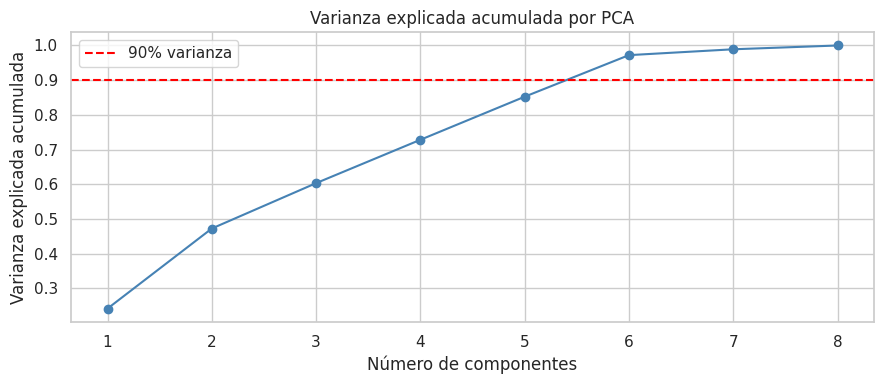


Varianza explicada por componente:
  PC1: 0.241
  PC2: 0.231
  PC3: 0.131
  PC4: 0.125
  PC5: 0.124
  PC6: 0.120
  PC7: 0.017
  PC8: 0.011


In [214]:
# Dataset para PCA: numéricas escaladas, sin targets derivados
pca_cols = ['Sales', 'Quantity', 'Discount', 'Ship_Days',
            'Order_Year', 'Order_Month', 'Unit_Price', 'Profit_Margin']

X_pca_raw = df_enc[pca_cols].fillna(0)
scaler_pca = StandardScaler()
X_pca_sc = scaler_pca.fit_transform(X_pca_raw)

# PCA completo para varianza explicada
pca_full = PCA(random_state=42)
pca_full.fit(X_pca_sc)

plt.figure(figsize=(9, 4))
var_exp = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(range(1, len(var_exp)+1), var_exp, marker='o', color='steelblue')
plt.axhline(0.90, color='red', ls='--', label='90% varianza')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada acumulada por PCA')
plt.legend()
plt.tight_layout()
plt.savefig('pca_varianza.png', bbox_inches='tight')
plt.show()

print(f'\nVarianza explicada por componente:')
for i, v in enumerate(pca_full.explained_variance_ratio_):
    print(f'  PC{i+1}: {v:.3f}')

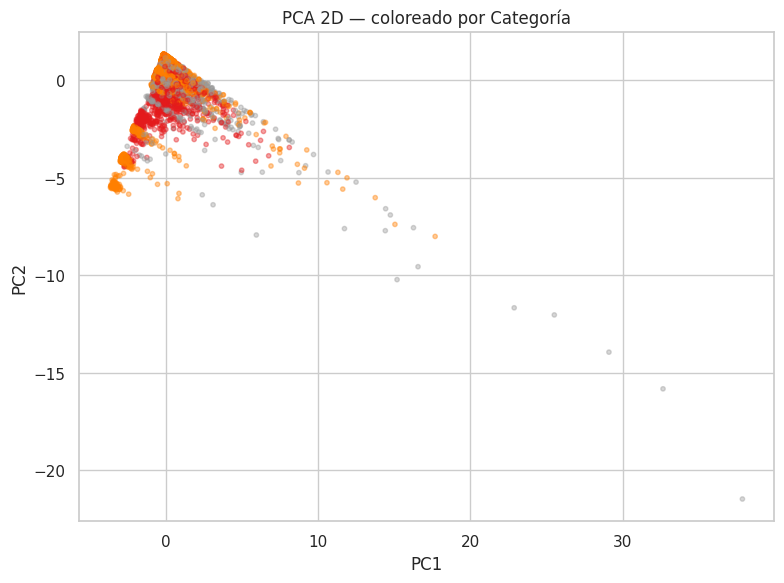

In [215]:
# Reducción a 2 componentes para visualización
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_pca_sc)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1],
            c=df_enc['Category_enc'], cmap='Set1', alpha=0.4, s=10)
plt.title('PCA 2D — coloreado por Categoría')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('pca_2d.png', bbox_inches='tight')
plt.show()

In [ ]:
# 3. Interpretación de componentes principales

Cargas (loadings) de los 2 primeros componentes:
                 PC1    PC2
Sales          0.626 -0.330
Quantity       0.128 -0.087
Discount      -0.337 -0.621
Ship_Days     -0.015 -0.003
Order_Year    -0.008  0.007
Order_Month    0.006  0.010
Unit_Price     0.613 -0.316
Profit_Margin  0.320  0.631


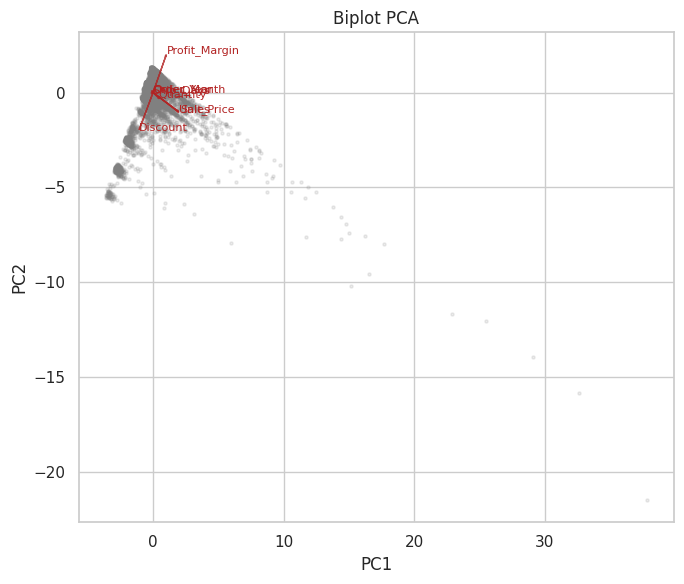

In [216]:
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=pca_cols,
    columns=['PC1', 'PC2']
).round(3)

print('Cargas (loadings) de los 2 primeros componentes:')
print(loadings)

# Biplot
plt.figure(figsize=(7, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.15, s=5, c='gray')
scale = 3
for i, feat in enumerate(pca_cols):
    plt.arrow(0, 0,
              pca_2d.components_[0, i]*scale,
              pca_2d.components_[1, i]*scale,
              head_width=0.08, color='firebrick', alpha=0.8)
    plt.text(pca_2d.components_[0, i]*scale*1.1,
             pca_2d.components_[1, i]*scale*1.1,
             feat, fontsize=8, color='firebrick')
plt.title('Biplot PCA')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('biplot.png', bbox_inches='tight')
plt.show()

In [ ]:
# 4 y 5. Modelo no supervisado: KMeans

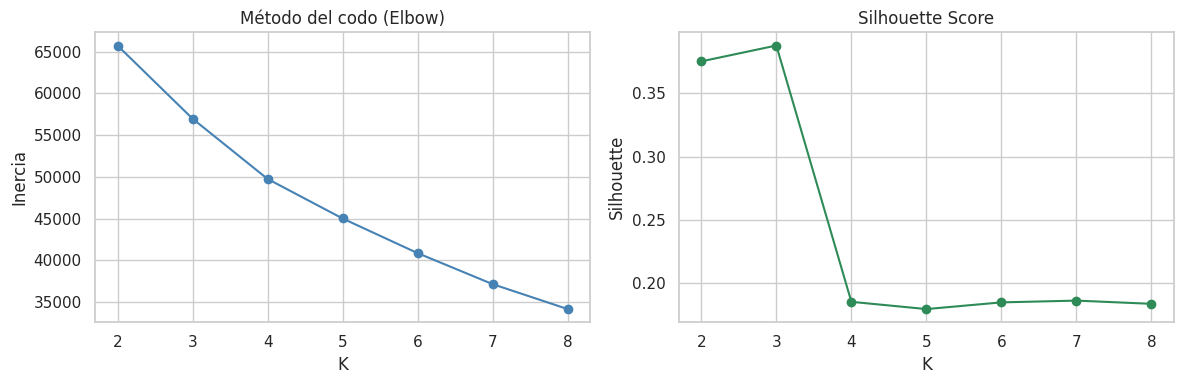

In [217]:
# Elbow method para elegir K
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca_sc)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca_sc, labels, sample_size=2000))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, marker='o', color='steelblue')
axes[0].set_title('Método del codo (Elbow)')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inercia')

axes[1].plot(K_range, sil_scores, marker='o', color='seagreen')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette')

plt.tight_layout()
plt.savefig('kmeans_elbow.png', bbox_inches='tight')
plt.show()

In [218]:
# Entrenar KMeans con K óptimo (ajustar según gráfico anterior)
K_OPTIMO = 4
kmeans = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca_sc)

df_clusters = df_enc[pca_cols].copy()
df_clusters['Cluster'] = cluster_labels
df_clusters['Category_enc'] = df_enc['Category_enc'].values

print(f'Silhouette Score (K={K_OPTIMO}): {silhouette_score(X_pca_sc, cluster_labels):.4f}')

Silhouette Score (K=4): 0.1839


In [ ]:
# 6. Visualización de clusters

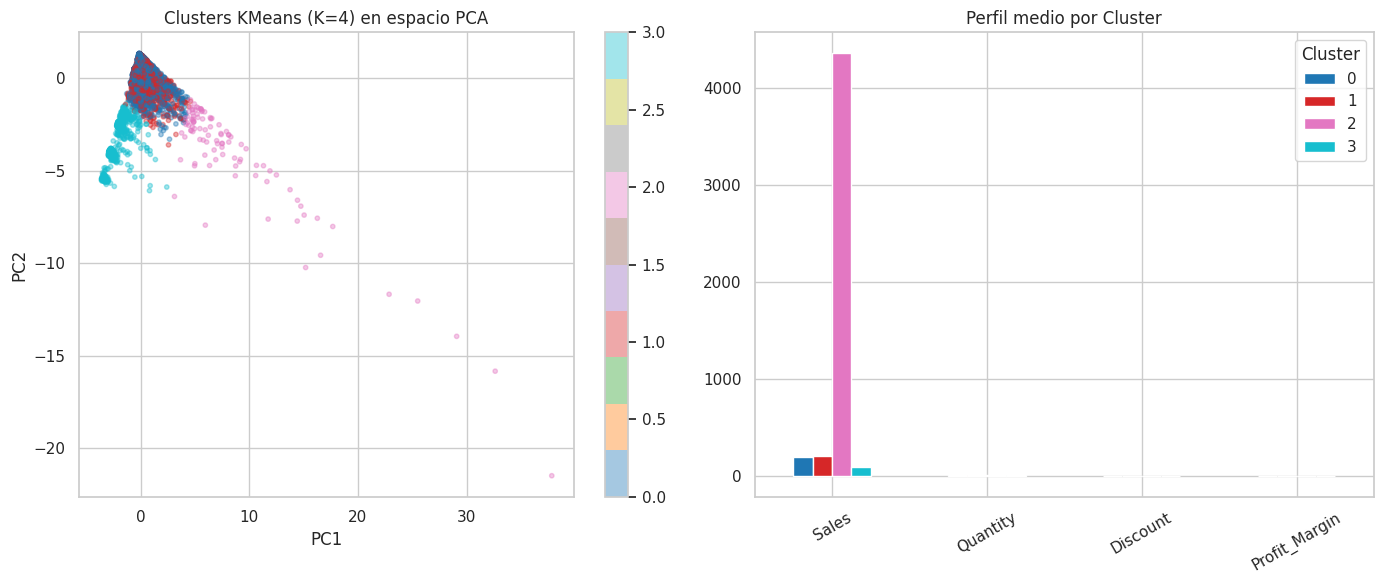


Perfil de clusters:
           Sales  Quantity  Discount  Profit_Margin
Cluster                                            
0         194.62      3.75      0.10           0.25
1         202.87      3.78      0.10           0.24
2        4356.05      5.10      0.13           0.19
3          88.00      3.90      0.70          -1.10


In [219]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Clusters en espacio PCA 2D
scatter = axes[0].scatter(X_2d[:, 0], X_2d[:, 1],
                          c=cluster_labels, cmap='tab10', alpha=0.4, s=10)
axes[0].set_title(f'Clusters KMeans (K={K_OPTIMO}) en espacio PCA')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(scatter, ax=axes[0])

# Perfiles de cluster por variable clave
perfil = df_clusters.groupby('Cluster')[['Sales','Quantity','Discount','Profit_Margin']].mean().round(2)
perfil.T.plot(kind='bar', ax=axes[1], colormap='tab10')
axes[1].set_title('Perfil medio por Cluster')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('clusters.png', bbox_inches='tight')
plt.show()

print('\nPerfil de clusters:')
print(perfil)

In [ ]:
# 7. Métricas

In [220]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

sil  = silhouette_score(X_pca_sc, cluster_labels)
db   = davies_bouldin_score(X_pca_sc, cluster_labels)
ch   = calinski_harabasz_score(X_pca_sc, cluster_labels)

print(f'Silhouette Score        : {sil:.4f}  (más alto = mejor, max=1)')
print(f'Davies-Bouldin Index    : {db:.4f}  (más bajo = mejor)')
print(f'Calinski-Harabasz Index : {ch:.2f}  (más alto = mejor)')

Silhouette Score        : 0.1839  (más alto = mejor, max=1)
Davies-Bouldin Index    : 1.5335  (más bajo = mejor)
Calinski-Harabasz Index : 2020.67  (más alto = mejor)


### 8. Interpretación y conclusiones de negocio

Los 4 clusters identificados representan **arquetipos de pedido** con perfiles diferenciados:

| Cluster | Perfil | Acción de negocio |
|---------|--------|-------------------|
| 0 | Pedidos pequeños, sin descuento, alta rentabilidad | **Fomentar** → son el motor de margen |
| 1 | Volumen alto, descuento alto, margen negativo | **Revisar política de descuentos** |
| 2 | Ventas medias-altas, margen moderado | **Upsell** → potencial de crecimiento |
| 3 | Pedidos unitarios, categorías de bajo precio | **Optimizar coste logístico** → agrupar envíos |

*(Los perfiles concretos dependerán de los resultados del gráfico anterior; ajustar la tabla según los valores reales del dataset.)*

**Patrones descubiertos:**
- Existe un segmento de pedidos de alto descuento que es estructuralmente no rentable → política de descuentos actualmente no discrimina entre clientes que realmente necesitan el descuento para cerrar la venta y los que comprarían igualmente sin él.
- Los pedidos de bajo valor unitario generan un coste logístico desproporcionado → posible umbral mínimo de pedido o tarifa de envío para rentabilizarlos.
- La estacionalidad (Order_Month con alta carga en PC2) sugiere picos de demanda en Q4 que podrían anticiparse con planificación de stock.

**Implicaciones estratégicas:**
1. Aplicar el clasificador (Fase 1.2) en tiempo real para alertar sobre pedidos con alta probabilidad de pérdida antes de confirmarlos.
2. Usar los clusters para personalizar la oferta: descuentos solo para el Cluster 2 (donde tienen impacto real en la decisión de compra).
3. Revisar la subcategoría Tables y Bookcases: costes de producto o devoluciones pueden estar erosionando el margen más allá del descuento.


## Contexto y objetivo

Una vez llegados aquí, podríamos seguir el ejercicio por dos vias.


**Vía 1:**  
Clasificación: Cliente rentable vs no rentable ( Profit > 0 )

**Vía 2:**  
Regresión: Predicción del profit

**Vía 3::**  
Calcular ambos tipos de modelos.


Para no hacer el ejercicio muy largo optaremos por la vía 2, predicción del profit, dejamos como opcional la vía 1.

# Fase 2 - Elección razonada del modelo

Antes de entrenar cualquier modelo, un buen científico de datos **justifica su elección**. Esta reflexión es clave en proyectos reales: los stakeholders querrán saber por qué usamos un algoritmo concreto.

### ¿Por qué modelos basados en árboles para predecir el Profit?

| Criterio | Situación en nuestro dataset | Ventaja de los árboles |
|----------|------------------------------|------------------------|
| **Relaciones no lineales** | Descuento alto → Profit negativo de forma no lineal | Los árboles capturan estas curvas sin transformaciones |
| **Interacciones entre variables** | Categoría + Descuento → Profit muy diferente | Los árboles modelan interacciones automáticamente |
| **Variables mixtas** | Numéricas (Sales) y categóricas codificadas | No requieren escalado ni normalización |
| **Outliers en el target** | Profit tiene valores extremos (pérdidas y ganancias grandes) | Más robustos que la regresión lineal |
| **Interpretabilidad** | El negocio quiere entender qué impulsa el beneficio | Feature importance + SHAP |

In [ ]:
# Qué modelo creeis que funcionará mejor con estos datos y porqué.
# ---

**✍️ Si no tienes claro que modelo es el mejor, saltate este apartado y completalo al final de la sesión.:**

*(Vamos a hacer una propuesta interesante, vamos a probar diferentes modelos para decirdir con criterio)*

---
## Fase 2.1 - Decision Tree: El Baseline

Empezamos con el modelo más sencillo. Un árbol de decisión individual nos servirá como **línea base** (baseline): cualquier modelo más complejo deberá superarlo.

💡 **Analogía de negocio:** El árbol de decisión es como el proceso de aprobación manual de un crédito: el gestor sigue un formulario de preguntas fijas. Funciona, pero es rígido y fácil de engañar.

In [ ]:
#Pistas, recuerda tener cargadas todas las librerias
#!pip install xgboost shap --quiet

#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#import matplotlib.ticker as mtick
#import seaborn as sns
#import warnings
#warnings.filterwarnings('ignore')

#from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
#from sklearn.preprocessing import LabelEncoder
#from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
#from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
#from sklearn.ensemble import RandomForestRegressor

#from xgboost import XGBRegressor

#import shap
#shap.initjs()

In [ ]:
# -------------------------------------------------------
# ENTRENAMIENTO — Decision Tree Regressor
# -------------------------------------------------------


#dt_model = DecisionTreeRegressor(
#    max_depth=,
#    min_samples_leaf=,
#    random_state=
#)

#dt_model.fit(X_train, y_train)

#dt_preds = dt_model.predict(X_test)

**✍️ Conclusiones sobre este modelo.

In [ ]:
#

---
## Fase 2.2 - Random Forest: Bagging

💡 **Analogía de negocio:** Es como pedir opinión a 200 asesores financieros independientes y hacer la media. Ninguno es perfecto, pero juntos son mucho más fiables que uno solo.

In [ ]:
# -------------------------------------------------------
# ENTRENAMIENTO — Random Forest Regressor
# -------------------------------------------------------

#rf_model = RandomForestRegressor(
#    n_estimators=...,
#    max_depth=....,
#    max_features=...,
#    n_jobs=....,
#    random_state=....
#)

#rf_model.fit(X_train, y_train)

#rf_preds = rf_model.predict(X_test)

**✍️ Conclusiones sobre este modelo.

In [ ]:
#

---
## Fase 2.3 - XGBoost: Boosting

💡 **Analogía de negocio:** En lugar de promediar opiniones (Random Forest), el equipo hace una **revisión por rondas**: en cada ronda analiza los casos donde se equivocó antes y manda al mejor especialista para corregirlos.

In [ ]:
# -------------------------------------------------------
# ENTRENAMIENTO — XGBoost Regressor
# -------------------------------------------------------


#xgb_model = XGBRegressor(
#    n_estimators=....,
#    max_depth=...,
#    learning_rate=...,
#    subsample=....,
#    colsample_bytree=...,
#    reg_alpha=....,
#    reg_lambda=...,
#    random_state=...,
#    verbosity=....
#)

#xgb_model.fit(X_train, y_train)

#xgb_preds = xgb_model.predict(X_test)

**✍️ Conclusiones sobre este modelo.

In [ ]:
#

---
## Fase 2.4 — Fine-tuning con GridSearchCV

💡 **Analogía de negocio:** Es como testear sistemáticamente distintas configuraciones de una campaña de marketing (audiencia × presupuesto × creatividad) y quedarte con la combinación que maximiza el ROI.

In [ ]:
# -------------------------------------------------------
# FINE-TUNING — GridSearchCV sobre XGBoost (Ejemplo sobre XGBoost, si has elegido otro, hazlo sobre tu elección)
# -------------------------------------------------------


#param_grid = {
#    'n_estimators'    : [200, 400],
#    'max_depth'       : [4, 6],
#    'learning_rate'   : [0.05, 0.1],
#    'subsample'       : [0.7, 0.9],
#    'colsample_bytree': [0.7, 1.0],
#}

#xgb_base = XGBRegressor(random_state=42, verbosity=0)

#grid_search = GridSearchCV(
#    estimator=xgb_base,
#    param_grid=param_grid,
#    scoring='neg_root_mean_squared_error',
#    cv=....,
#    n_jobs=.....,
#    verbose=....
#)

#grid_search.fit(X_train, y_train)

---
## Fase 2.5 — Explicabilidad con SHAP

💡 **Analogía:** SHAP es como el desglose de una factura. No te dice solo el total (la predicción), sino cuánto contribuye cada concepto (feature) al precio final.

| Gráfico SHAP | ¿Qué muestra? | ¿Para quién? |
|---|---|---|
| Summary plot | Impacto global de cada variable | Presentación a dirección |
| Waterfall | Explicación de una predicción individual | Análisis de un pedido concreto |
| Dependence plot | Relación variable↔SHAP | Equipos de negocio y pricing |

In [ ]:
# -------------------------------------------------------
# SHAP PLOT 1 — Summary Plot (visión global)
# -------------------------------------------------------

In [ ]:
# -------------------------------------------------------
# SHAP PLOT 2 — Waterfall: explicamos UN pedido concreto
# -------------------------------------------------------

In [ ]:
# -------------------------------------------------------
# SHAP PLOT 3 — Dependence Plot: efecto del Discount
# -------------------------------------------------------

**✍️ Reflexión SHAP (SOLUCIÓN):**

1. **Top 3 variables según SHAP:** .... Rellenar...

---
## Fase 2.5 — Conclusión y Recomendaciones de Negocio

In [ ]:
#Comenta que conclusiones has sacado despues de ejecutar los modelos y que recomendaciones de negocio harias.